<a href="https://colab.research.google.com/github/pauloengcsantos/multiclass-damage-segmentation/blob/main/Transfer_YOLOv8%2BSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparando o ambiente

In [ ]:
#Montar o GDrive no seu projeto
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#Acessar o arquivo do Google Drive
import os
os.chdir("gdrive/MyDrive")

# YOLOv8 Installation

In [ ]:
#Criar uma pasta YOLO (Caso já exista no GDrive, desconsidere)
!mkdir yolov8-architecture

In [ ]:
#Ir até pasta da YOLOv8 já criada
%cd yolov8-architecture

[Errno 2] No such file or directory: 'yolov8-architecture'
/content/gdrive/MyDrive/yolov8-architecture


In [ ]:
#Instalar YOLOv8
%pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.3.35 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 37.4/235.7 GB disk)


# YOLOv8 Architecture

In [ ]:
# Download the YOLOv8 Architecture File
!wget https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/models/v8/yolov8.yaml

--2024-09-19 00:08:37--  https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/models/v8/yolov8.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1889 (1.8K) [text/plain]
Saving to: ‘yolov8.yaml’

yolov8.yaml         100%[===================>]   1.84K  --.-KB/s    in 0.001s  

2024-09-19 00:08:37 (1.27 MB/s) - ‘yolov8.yaml’ saved [1889/1889]



<div>
  <img src="https://www.stunningvisionai.com/course/yolov8-architecture.png" height="750"/>
</div>

In [ ]:
# Create YOLOv8l Architecture
!cp yolov8.yaml yolov8l.yaml

## Modified YOLOv8 Architecture for Small Objects

In [ ]:
# Copy YOLOv8l Small Architecture
!cp yolov8.yaml yolov8l-small.yaml

<div>
  <img src="https://www.stunningvisionai.com/course/yolov8-architecture-modification-for-small-object.png" height="685"/>
</div>

<div>
  <img src="https://www.stunningvisionai.com/course/yolov8-architecture-for-small-object.png" height="692"/>
</div>

### Download the dataset

In [ ]:
# Create data folder
!mkdir data

In [ ]:
# Go to the data folder
%cd data

/content/gdrive/MyDrive/yolov8-architecture/data


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="KKJtYo0ZnTvR464jFtHG")
project = rf.workspace("peccunb-u9u9q").project("shm-bafca-hk95g")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.2.100, to fix: `pip install ultralytics==8.0.196`



Extracting Dataset Version Zip to SHM-1 in yolov8:: 100%|██████████| 17279/17279 [01:52<00:00, 153.88it/s]


### Download the data file

In [ ]:
# Go to the root folder
%cd ../

/content/gdrive/MyDrive/yolov8-architecture


### Training

In [ ]:
# Training Original Model
!yolo detect train model=yolov8l.yaml data=data/data.yaml workers=2 batch=12 device=0 epochs=300 patience=50 name=yolov8_SHM-1

Ultralytics YOLOv8.2.101 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=detect, mode=train, model=yolov8l.yaml, data=data/data.yaml, epochs=300, time=None, patience=50, batch=12, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=yolov8_SHM-1, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxe

### Training a Modified Model (Small Objects)

In [ ]:
# Training a Modified Model (Small Objects)
!yolo detect train model=yolov8l-small.yaml data=data/data.yaml workers=2 batch=12 device=0 epochs=300 patience=30 imgsz=480 name=yolov8_SHM-1_small

Ultralytics YOLOv8.2.100 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=detect, mode=train, model=yolov8l-small.yaml, data=data/data.yaml, epochs=300, time=None, patience=30, batch=12, imgsz=480, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=yolov8_SHM-1_small2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tr

### Speed

Download the video

In [ ]:
# Create inference folder
!mkdir inference

In [ ]:
# Download the video
!gdown https://drive.google.com/uc?id=1duhxIqqerdmmzKdPfDbN5JGP5HcE6Ufl

In [ ]:
# Move the video to inference folder
!mv sperm.mp4 inference/

Speed

In [ ]:
import cv2
import random
import time
import argparse
import os
from ultralytics import YOLO

def get_name(file_path):
  name_idx = 0
  file_pos = (file_path).rfind('\\')

  if(file_pos == -1):
      file_pos = (file_path).rfind('/')

      if(file_pos == -1):
          file_pos = 0

  name_idx = file_pos + 1

  name = file_path[name_idx:]

  return name

def get_save_path(file_name, folder_name):
  path = "result"
  save_path = os.path.join(path, folder_name)

  exists = os.path.exists(save_path)

  if(not exists):
      os.makedirs(save_path)

  save_path = os.path.join(save_path, file_name)

  return save_path

def draw_box(img, result, class_list, colors, label_size) :
  # Get information from result
  xyxy = result.boxes.xyxy.numpy()
  confidence = result.boxes.conf.numpy()
  class_id = result.boxes.cls.numpy().astype(int)
  # Pack together for easy use
  sum_output = list(zip(class_id, confidence, xyxy))
  # Copy image, in case that we need original image for something
  out_image = img.copy()

  for run_output in sum_output :
    # Unpack
    label, con, box = run_output
    # Choose color
    box_color = colors[int(label)]
    text_color = (255,255,255)
    # Get Class Name
    label = class_list[int(label)]
    # Draw object box
    first_half_box = (int(box[0]),int(box[1]))
    second_half_box = (int(box[2]),int(box[3]))
    cv2.rectangle(out_image, first_half_box, second_half_box, box_color, 2)
    # Create text
    text_print = '{label} {con:.2f}'.format(label = label, con = con)
    # Locate text position
    text_location = (int(box[0]), int(box[1] - 10 ))
    # Get size and baseline
    labelSize, baseLine = cv2.getTextSize(text_print, cv2.FONT_HERSHEY_SIMPLEX, label_size, 1)

    # Draw text's background
    cv2.rectangle(out_image
                    , (int(box[0]), int(box[1] - labelSize[1] - 10 ))
                    , (int(box[0])+labelSize[0], int(box[1] + baseLine-10))
                    , box_color , cv2.FILLED)
    # Put text
    cv2.putText(out_image, text_print ,text_location
                , cv2.FONT_HERSHEY_SIMPLEX , label_size
                , text_color, 2, cv2.LINE_AA)

  return out_image

def draw_fps(avg_fps, combined_img):
  avg_fps_str = float("{:.2f}".format(avg_fps))

  cv2.rectangle(combined_img, (10,2), (280,50), (255,255,255), -1)
  cv2.putText(combined_img, "FPS: "+str(avg_fps_str), (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0,255,0), thickness=3)

  return combined_img

In [ ]:
def detection(source, model, folder_name, img_size, label_size=1):
  # Initialize video
  cap = cv2.VideoCapture(source)

  # Initialize YOLOv8 model
  model_path = model
  yolov8_detector = YOLO(model_path)

  # Class Name and Colors
  label_map = yolov8_detector.names
  COLORS = [[random.randint(0, 255) for _ in range(3)] for _ in label_map]

  # FPS Detection
  frame_count = 0
  total_fps = 0
  avg_fps = 0

  # FPS Video
  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  frame_width = int(cap.get(3))
  frame_height = int(cap.get(4))

  video_frames = []

  while cap.isOpened():
    # Press key q to stop
    if cv2.waitKey(1) == ord('q'):
        break

    try:
        # Read frame from the video
        ret, frame = cap.read()
        if not ret:
            break
    except Exception as e:
        print(e)
        continue

    # # Start Time
    start = time.time()
    # Update object localizer
    results = yolov8_detector.predict(frame, imgsz=img_size, verbose=False)
    result = results[0].cpu()

    # Draw Detection Results
    combined_img = draw_box(frame, result, label_map, COLORS, label_size)

    end = time.time()
    # # End Time

    # Draw FPS
    frame_count += 1
    fps = 1 / (end - start)
    total_fps = total_fps + fps
    avg_fps = total_fps / frame_count

    combined_img = draw_fps(avg_fps, combined_img)

    # Append frame to array
    video_frames.append(combined_img)

    #
    print("(%2d / %2d) Frames Processed" % (frame_count, total_frames))

  print("\nCreate a Video:")

  # Get a file name
  file_name = get_name(source)
  # Get Save Path
  save_path = get_save_path(file_name, folder_name)
  # Create VideoWriter object.
  out = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*'XVID'), int(avg_fps), (frame_width, frame_height))

  for frame in video_frames:
    out.write(frame)

  out.release()

  print("Video is saved in: "+save_path)

In [ ]:
# Original YOLOv8 Model
detection("inference/sperm.mp4", "runs/detect/yolov8_sperm/weights/best.pt", "yolov8l-sperm", 640)

In [ ]:
# Download the result
from google.colab import files

files.download('result/yolov8l-sperm/sperm.mp4')

In [ ]:
# Modified YOLOv8 Model
detection("inference/sperm.mp4", "runs/detect/yolov8_sperm_small/weights/best.pt", "yolov8l-sperm-small", 640)

In [ ]:
# Download the result
from google.colab import files

files.download('result/yolov8l-sperm-small/sperm.mp4')

## Modified YOLOv8 Architecture for Medium Objects

In [ ]:
# Copy YOLOv8l Medium Architecture
!cp yolov8.yaml yolov8l-medium.yaml

<div>
  <img src="https://www.stunningvisionai.com/course/yolov8-architecture-modification-for-medium-object.png" height="685"/>
</div>

<div>
  <img src="https://www.stunningvisionai.com/course/yolov8-architecture-for-medium-object.png" height="685"/>
</div>

### Training a Modified Model (Medium Objects)

In [ ]:
# Training a Modified Model (Medium Objects)
!yolo detect train model=yolov8l-medium.yaml data=data/data.yaml workers=2 batch=12 device=0 epochs=300 patience=30 imgsz=1280 name=yolov8_SHM-1_medium

Ultralytics YOLOv8.2.100 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=detect, mode=train, model=yolov8l-medium.yaml, data=data/data.yaml, epochs=300, time=None, patience=30, batch=12, imgsz=1280, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=yolov8_SHM-1_medium3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf

## Modified YOLOv8 Architecture for Big Objects

In [ ]:
# Copy YOLOv8l Big Architecture
!cp yolov8.yaml yolov8l-big.yaml

<div>
  <img src="https://www.stunningvisionai.com/course/yolov8-architecture-modification-for-big-object.png" height="685"/>
</div>

<div>
  <img src="https://www.stunningvisionai.com/course/yolov8-architecture-for-big-object.png" height="720"/>
</div>

### Training

In [ ]:
# Training Original Model
!yolo detect train model=yolov8l.yaml data=data/data.yaml workers=2 batch=12 device=0 epochs=100 patience=50 name=yolov8_tomato_leaf

### Training a Modified Model (Big Objects)

In [ ]:
# Training a Modified Model (Big Objects)
!yolo detect train model=yolov8l-big.yaml data=data/data.yaml workers=2 batch=12 device=0 epochs=300 patience=30 imgsz=1280 name=yolov8_SHM-1_big

Ultralytics YOLOv8.2.100 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=detect, mode=train, model=yolov8l-big.yaml, data=data/data.yaml, epochs=300, time=None, patience=30, batch=12, imgsz=1280, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=yolov8_SHM-1_big, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, 

### Speed

Download the image

In [ ]:
# Download the image
!gdown https://drive.google.com/uc?id=1ivZMXvi3vUFQQXPdZdkAyYH9Q8LYUjdp

In [ ]:
# Move the image to inference folder
!mv tomato_healthy.JPG inference/

Inference

In [ ]:
# Original YOLOv8 model
!yolo detect predict model=runs/detect/yolov8_tomato_leaf/weights/best.pt source=inference/tomato_healthy.JPG save=True

Show detection result

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
  img = mpimg.imread(image_path)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

In [ ]:
# Original YOLOv8 model
show_image("runs/detect/predict/tomato_healthy.JPG")

In [ ]:
# Modified YOLOv8 model
show_image("runs/detect/predict2/tomato_healthy.JPG")

# YOLOv8 for big objects with TensorRT

In [ ]:
!pip install tensorrt tensorrt_lean tensorrt_dispatch

NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

In [ ]:
!pip install onnx onnxsim onnxruntime-gpu

NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

## Convert the Model


In [ ]:
# Export YOLOv8 Model to Tensorrt
!yolo export model=runs/detect/yolov8_SHM-1/weights/best.pt format=engine half=True device=0

Ultralytics YOLOv8.2.101 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLOv8l summary (fused): 268 layers, 43,610,463 parameters, 0 gradients, 164.8 GFLOPs

PyTorch: starting from 'runs/detect/yolov8_SHM-1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (83.6 MB)
requirements: Ultralytics requirement ['onnxslim==0.1.34'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.3/140.3 kB 47.6 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 2.4s, installed 1 package: ['onnxslim==0.1.34']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.16.2 opset 19...
ONNX: slimming with onnxslim 0.1.34...
ONNX: export success ✅ 7.2s, saved as 'runs/detect/yolov8_SHM-1/weights/best.onnx' (166.6 MB)

TensorRT: starting export with TensorRT 10.4.0...
[09/26/2024-18:31:38] [TRT] [I] [MemUsageChange] Init CUDA: CPU +2, GPU +0, now: CPU 973, GPU 757 (MiB

## mAP

In [ ]:
# Original YOLOv8 model
!yolo detect val model=runs/detect/yolov8_SHM-1/weights/best.pt data=data/data.yaml iou=0.5 name=yolov8_SHM-1_best_val

Ultralytics YOLOv8.2.101 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLOv8l summary (fused): 268 layers, 43,610,463 parameters, 0 gradients, 164.8 GFLOPs
val: Scanning /content/gdrive/MyDrive/yolov8-architecture/data/SHM-1/labels/val.cache... 1288 images, 0 backgrounds, 0 corrupt: 100% 1288/1288 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 189, len(boxes) = 2840. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 81/81 [00:34<00:00,  2.36it/s]
                   all       1288       2840      0.952      0.911      0.952      0.894
         Efflorescence        406       1292       0.89      0.742      0.866      0.714
 Exposed_reinforcement        294        425      0.965      0.899      0.953      0.894

In [ ]:
# YOLOv8 for big objects with TensorRT
!yolo detect val model=runs/detect/yolov8_SHM-1/weights/best.engine data=data/data.yaml iou=0.5 name=yolov8_SHM-1_tensorrt_val

Ultralytics YOLOv8.2.101 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Loading runs/detect/yolov8_SHM-1/weights/best.engine for TensorRT inference...
[09/26/2024-19:03:08] [TRT] [I] Loaded engine size: 86 MiB
[09/26/2024-19:03:08] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +46, now: CPU 0, GPU 129 (MiB)
val: Scanning /content/gdrive/MyDrive/yolov8-architecture/data/SHM-1/labels/val.cache... 1288 images, 0 backgrounds, 0 corrupt: 100% 1288/1288 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 189, len(boxes) = 2840. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1288/1288 [00:19<00:00, 67.44it/s] 
                   all       1288       2840      0.938   

In [ ]:
# YOLOv8 for big objects with TensorRT
!yolo detect val model=runs/detect/yolov8_SHM-1/weights/best.onnx data=data/data.yaml iou=0.5 name=yolov8_SHM-1_tensorrt_val2

Ultralytics YOLOv8.2.101 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Loading runs/detect/yolov8_SHM-1/weights/best.onnx for ONNX Runtime inference...
2024-09-26 19:04:27.235283838 [W:onnxruntime:, transformer_memcpy.cc:74 ApplyImpl] 4 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
Setting batch=1 input of shape (1, 3, 640, 640)
val: Scanning /content/gdrive/MyDrive/yolov8-architecture/data/SHM-1/labels/val.cache... 1288 images, 0 backgrounds, 0 corrupt: 100% 1288/1288 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 189, len(boxes) = 2840. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class

## Speed

In [ ]:
# Original YOLOv8 model
!yolo detect predict model=runs/detect/yolov8_tomato_leaf/weights/best.pt source=inference/tomato_healthy.JPG save=True

In [ ]:
# YOLOv8 for big objects with TensorRT
!yolo detect predict model=runs/detect/yolov8_tomato_leaf_big/weights/best.engine source=inference/tomato_healthy.JPG save=True

# Transferencia Yolov8 para SAM

In [ ]:
!pip install roboflow ultralytics --quiet

In [ ]:
#Preparando o ambiente

import ultralytics
from IPython.display import display, Image
from roboflow import Roboflow
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
ultralytics.checks()

Ultralytics 8.3.35 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 37.4/235.7 GB disk)


In [ ]:
#baixando o modelo SAM e os pesos do repositório GitHub

first_run = True
if first_run:
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-3bhb2taq
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-3bhb2taq
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
--2024-11-22 00:47:43--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.68, 3.171.22.33, 3.171.22.13, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth.10’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G  45.7MB/s    in 32s     

2024-11-22 00:48:15 (76.8 MB/s) - ‘sam_vit_h_4b8939.pth.10’ saved [2564550879/2564550879]



#Yolov8 Predict Test

In [ ]:
# @title Incluir path da imagem
source_img = '/content/gdrive/MyDrive/yolov8-architecture/iou/artigo/Image_-695-_jpg.rf.5e8f0d1f45af2934bc31ab0b4bb1e9aa.jpg'# @param {"type":"string"}
source_img

'/content/gdrive/MyDrive/yolov8-architecture/iou/artigo/Image_-695-_jpg.rf.5e8f0d1f45af2934bc31ab0b4bb1e9aa.jpg'

In [ ]:
!yolo predict model=runs/detect/yolov8_SHM-1/weights/best.pt source={source_img}

Ultralytics 8.3.35 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLOv8l summary (fused): 268 layers, 43,610,463 parameters, 0 gradients, 164.8 GFLOPs

image 1/1 /content/gdrive/MyDrive/yolov8-architecture/iou/artigo/Image_-695-_jpg.rf.5e8f0d1f45af2934bc31ab0b4bb1e9aa.jpg: 640x640 1 crack, 11.4ms
Speed: 6.3ms preprocess, 11.4ms inference, 529.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict252
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
# @title Incluir path da detecção
source_result = 'predict252'# @param {"type":"string"}
source_result

'predict252'

In [ ]:
filename = source_img.replace("/iou/artigo/", "/runs/detect/" + source_result + "/")
filename

'/content/gdrive/MyDrive/yolov8-architecture/runs/detect/predict252/Image_-695-_jpg.rf.5e8f0d1f45af2934bc31ab0b4bb1e9aa.jpg'

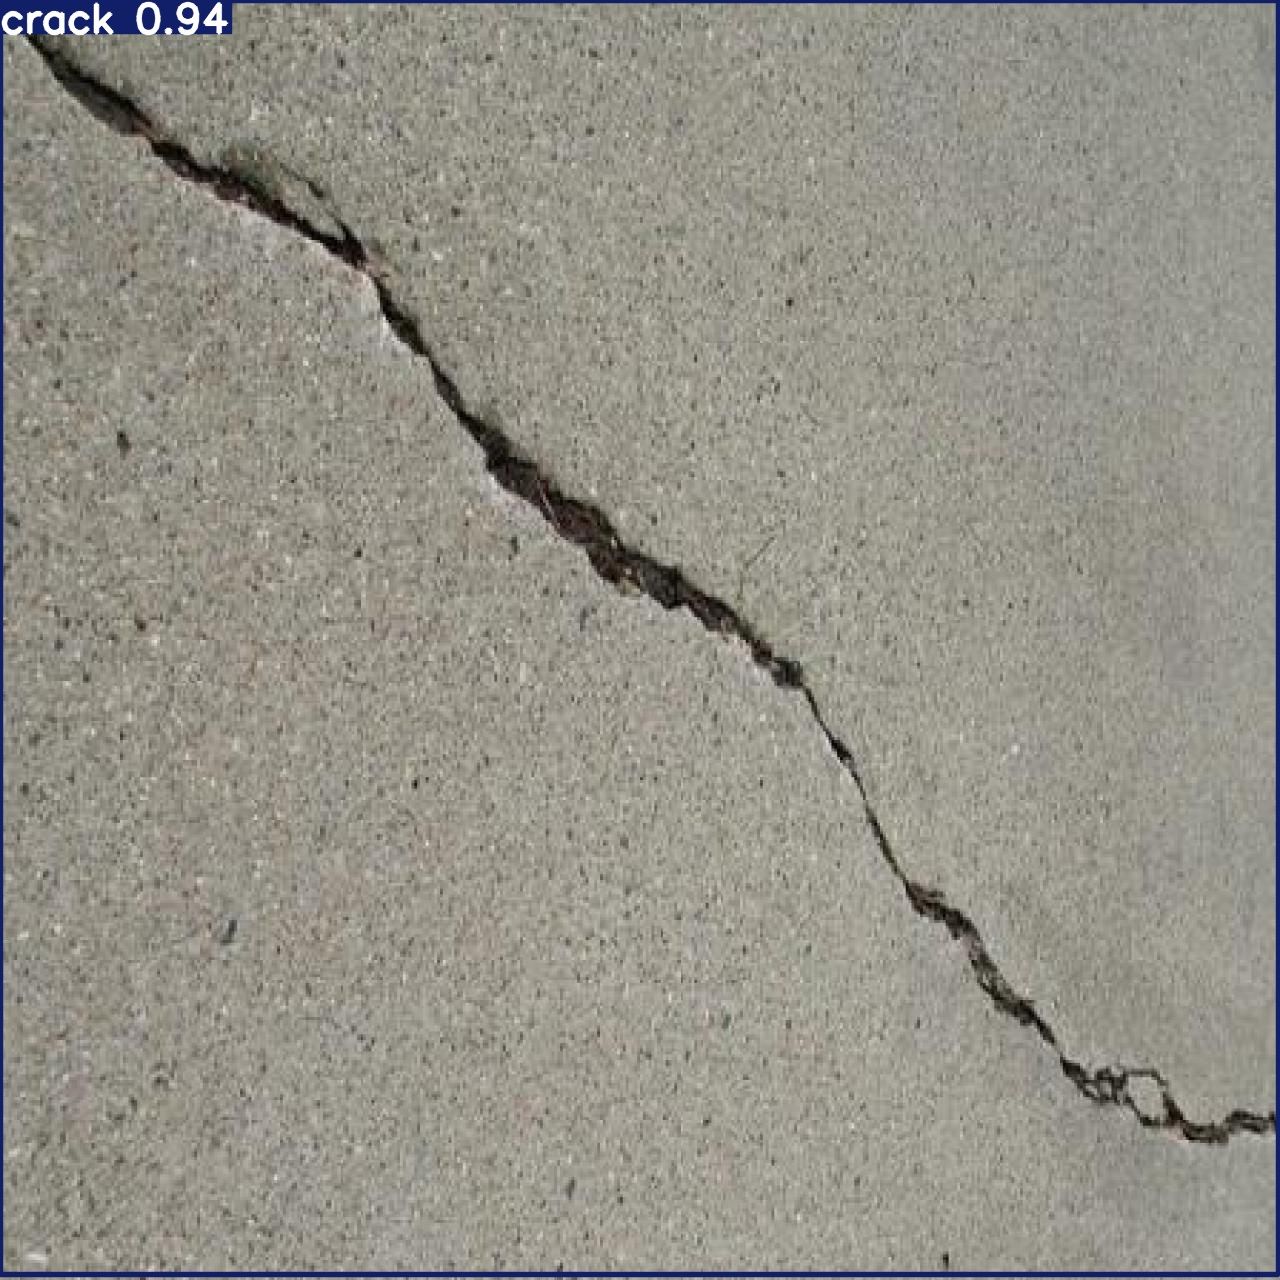

In [ ]:
Image(filename=filename, height=600)

In [ ]:
#!yolo predict model=runs/detect/yolov8_SHM-1/weights/best.pt source='/content/gdrive/MyDrive/yolov8-architecture/data/SHM-1/images/val/019_1w0t1lne-seh_jpg.rf.8286841b5e0aadcd21b4019f774f18ab.jpg'

In [ ]:
from ultralytics import YOLO
model = YOLO('runs/detect/yolov8_SHM-1/weights/best.pt')
results = model.predict(source=source_img, conf=0.25)


image 1/1 /content/gdrive/MyDrive/yolov8-architecture/iou/artigo/Image_-695-_jpg.rf.5e8f0d1f45af2934bc31ab0b4bb1e9aa.jpg: 640x640 1 crack, 11.9ms
Speed: 2.6ms preprocess, 11.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Efflorescence', 1: 'Exposed_reinforcement', 2: 'Ruststrain', 3: 'Scaling', 4: 'crack'}
 obb: None
 orig_img: array([[[ 25,  28,  32],
         [ 27,  30,  34],
         [ 31,  34,  38],
         ...,
         [139, 147, 146],
         [141, 149, 148],
         [139, 147, 146]],
 
        [[ 29,  32,  36],
         [ 31,  34,  38],
         [ 35,  38,  42],
         ...,
         [138, 146, 145],
         [140, 148, 147],
         [138, 146, 145]],
 
        [[ 25,  28,  32],
         [ 27,  30,  34],
         [ 29,  32,  36],
         ...,
         [136, 144, 143],
         [138, 146, 145],
         [136, 144, 143]],
 
        ...,
 
        [[137, 150, 152],
         [140, 153, 155],
         [138, 151, 153],
         ...,
         [145, 153, 153],
         [144, 152, 152],
         [143, 151, 151]],
 
        [[140, 153, 155],
      

### Extract Bounding Box

In [ ]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs

bbox=boxes.xyxy.tolist()[0]

In [ ]:
all_bboxes = []  # Lista para armazenar todas as caixas delimitadoras

for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs

    # Iterar por todas as caixas dentro de 'boxes'
    for box in boxes:
        bbox = box.xyxy.tolist()  # Converter para lista Python
        all_bboxes.append(bbox)  # Adicionar à lista principal

# Imprimir uma caixa por linha
for bbox in all_bboxes:
    print(bbox)

[[0.0, 0.0, 1278.593994140625, 1274.003173828125]]


In [ ]:
#image = cv2.cvtColor(cv2.imread('/content/gdrive/MyDrive/yolov8-architecture/data/SHM-1/images/val/019_1w0t1lne-seh_jpg.rf.8286841b5e0aadcd21b4019f774f18ab.jpg'), cv2.COLOR_BGR2RGB)

###Carregando o Modelo SAM (Não executar!)

In [ ]:
#Carregando o modelo SAM
import torch

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint).to(device=DEVICE)

In [ ]:
#Inicialize o gerador de máscaras.
mask_generator = SamAutomaticMaskGenerator(sam)

In [ ]:
!pip install supervision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 5.4 MB/s eta 0:00:00


In [ ]:
import cv2
import supervision as sv
import os

image = cv2.cvtColor(cv2.imread(source_img), cv2.COLOR_BGR2RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
'''import cv2
import supervision as sv
import os

image = cv2.cvtColor(cv2.imread('/content/gdrive/MyDrive/yolov8-architecture/data/SHM-1/images/val/019_1w0t1lne-seh_jpg.rf.8286841b5e0aadcd21b4019f774f18ab.jpg'), cv2.COLOR_BGR2RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

###Criando novo excel

In [ ]:
results_data = []

In [ ]:
for i, bbox in enumerate(all_bboxes):
    # Extrai a região da imagem correspondente à bbox
    x1, y1, x2, y2 = map(int, bbox[0])  # Access the first element of bbox, which contains the coordinates
    cropped_image_rgb = image_rgb[y1:y2, x1:x2]

    # Gera a máscara para a região extraída
    sam_result = mask_generator.generate(cropped_image_rgb)

    bbox_data = {
        'bbox_index': i,
        'x1': int(bbox[0][0]),
        'y1': int(bbox[0][1]),
        'x2': int(bbox[0][2]),
        'y2': int(bbox[0][3]),
        'area': sam_result[0]['area'],
        'predicted_iou': sam_result[0]['predicted_iou'],
        'stability_score': sam_result[0]['stability_score'],
    }
    results_data.append(bbox_data)

    # Cria um nome de variável dinâmico
    variable_name = f"sam_result_{i}"
    globals()[variable_name] = sam_result

    # Salva a imagem da máscara (opcional - para visualização)
    mask_image = np.zeros_like(cropped_image_rgb, dtype=np.uint8)
    mask_image[sam_result[0]['segmentation']] = 255

    save_path = os.path.join('/content/gdrive/MyDrive/yolov8-architecture/iou/result/202/', f"mask_{i}.png")
    cv2.imwrite(save_path, mask_image)

A geração de máscara retorna uma lista sobre máscaras, onde cada máscara é um dicionário contendo vários dados sobre a máscara. Essas chaves são:

* Segmentação: a máscara

* área: a área da máscara em pixels

* bbox: a caixa de limite da máscara no formato XYWH

* predicted_iou: a própria previsão do modelo para a qualidade da máscara

* point_coords: o ponto de entrada amostrado que gerou esta máscara

* stability_score: uma medida adicional da qualidade da máscara

* crop_box: o corte da imagem usada para gerar esta máscara no formato XYWH

In [ ]:
import numpy as np
import pandas as pd

results_df = pd.DataFrame(results_data)
print(results_df)

   bbox_index  x1  y1    x2    y2     area  predicted_iou  stability_score
0           0   0   0  1278  1274  1616375       0.975789         0.952135


In [ ]:
import pandas as pd
import os

def save_or_append_excel(results_df, file_path, source_img):
  """Saves results to an Excel file, creating a new file or appending to an existing one.

  Args:
    results_df: DataFrame containing results.
    file_path: Path to the Excel file.
    source_img: Path to the source image.
  """
  try:
    # Check if the file exists
    if os.path.exists(file_path):
      # Read existing Excel file into a DataFrame
      existing_df = pd.read_excel(file_path)

      # Append the new data
      results_df['source_img'] = source_img  # Add the source_img column
      updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    else:
      # Create a new DataFrame with the source_img column
      results_df['source_img'] = source_img
      updated_df = results_df

    # Save the updated DataFrame to the Excel file
    updated_df.to_excel(file_path, index=False)
    print(f"Results saved to {file_path}")
  except Exception as e:
    print(f"An error occurred: {e}")

# Example usage (assuming results_df and source_img are defined in your script):
file_path = '/content/gdrive/MyDrive/yolov8-architecture/iou/results.xlsx'
save_or_append_excel(results_df, file_path, source_img)

Results saved to /content/gdrive/MyDrive/yolov8-architecture/iou/results.xlsx


In [ ]:
#import shutil

In [ ]:
destination_folder = '/content/gdrive/MyDrive/yolov8-architecture/iou/artigo/done'

# Ensure the destination folder exists
os.makedirs(destination_folder, exist_ok=True)

# Construct the full destination path
destination_path = os.path.join(destination_folder, os.path.basename(source_img))

# Move the file
try:
    shutil.move(source_img, destination_path)
    print(f"File '{source_img}' moved to '{destination_path}' successfully.")
except FileNotFoundError:
    print(f"Error: Source file '{source_img}' not found.")
except shutil.Error as e:
    print(f"Error moving file: {e}")

File '/content/gdrive/MyDrive/yolov8-architecture/iou/artigo/Image_-695-_jpg.rf.5e8f0d1f45af2934bc31ab0b4bb1e9aa.jpg' moved to '/content/gdrive/MyDrive/yolov8-architecture/iou/artigo/done/Image_-695-_jpg.rf.5e8f0d1f45af2934bc31ab0b4bb1e9aa.jpg' successfully.




---



In [ ]:
!pip install supervision --upgrade # Upgrade to the latest version of supervision
import supervision as sv
import numpy as np

In [ ]:
for i, bbox in enumerate(all_bboxes):
    select_mask = mask_image[5:10]
    # Use titles instead of captions
    sv.plot_images_grid(
        images=select_mask,
        grid_size=(5, 2),
        size=(64, 64),
        titles=[f"predicted_iou: {result['predicted_iou']}" for result in results_data[5:10]]
    )
    break  # Add a break statement to only plot the first bbox

In [ ]:
#sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
#predictor = SamPredictor(sam)
#predictor.set_image(image)

In [ ]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

In [ ]:
input_box = np.array(bbox)

### Convert Bounding Box to Segmentation Mask

In [ ]:
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=True,
)

plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')

(-0.5, 952.5, 952.5, -0.5)

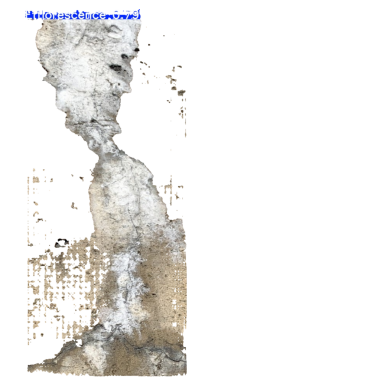

In [ ]:
segmentation_mask = masks[0]
binary_mask = np.where(segmentation_mask > 0.5, 1, 0)

white_background = np.ones_like(image) * 255

new_image = white_background * (1 - binary_mask[..., np.newaxis]) + image * binary_mask[..., np.newaxis]

plt.imshow(new_image.astype(np.uint8))
plt.axis('off')
plt.show()

##Benchmark

In [ ]:
from ultralytics.utils.benchmarks import benchmark

# Benchmark on GPU
benchmark(model="yolov8n.pt", data="data.yaml", imgsz=640, half=False, device=0)

Setup complete ✅ (12 CPUs, 83.5 GB RAM, 42.9/235.7 GB disk)

Benchmarks complete for yolov8n.pt on data.yaml at imgsz=640 (282.41s)
                   Format Status❔  Size (MB) metrics/mAP50-95(B) Inference time (ms/im)   FPS
0                 PyTorch       ❎        6.2                None                   None  None
1             TorchScript       ❎       12.5                None                   None  None
2                    ONNX       ❎       12.2                None                   None  None
3                OpenVINO       ❌        0.0                None                   None  None
4                TensorRT       ❎       14.6                None                   None  None
5                  CoreML       ❌        0.0                None                   None  None
6   TensorFlow SavedModel       ❎       30.6                None                   None  None
7     TensorFlow GraphDef       ❎       12.3                None                   None  None
8         TensorFlow L

,Format,Status❔,Size (MB),metrics/mAP50-95(B),Inference time (ms/im),FPS
0,PyTorch,❎,6.2,None,None,None
1,TorchScript,❎,12.5,None,None,None
2,ONNX,❎,12.2,None,None,None
3,OpenVINO,❌,0.0,None,None,None
4,TensorRT,❎,14.6,None,None,None
5,CoreML,❌,0.0,None,None,None
6,TensorFlow SavedModel,❎,30.6,None,None,None
7,TensorFlow GraphDef,❎,12.3,None,None,None
8,TensorFlow Lite,❌,0.0,None,None,None
9,TensorFlow Edge TPU,❌,0.0,None,None,None


from matplotlib import pyplot as plt
_df_0['Size (MB)'].plot(kind='hist', bins=20, title='Size (MB)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('Status❔').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Size (MB)'].plot(kind='line', figsize=(8, 4), title='Size (MB)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['Status❔'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='Size (MB)', y='Status❔', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
%cd /content/gdrive/MyDrive/yolov9

/content/gdrive/MyDrive/yolov9


In [ ]:
# prompt: get desempenho metrics from /content/gdrive/MyDrive/yolov9/runs/train/exp3/weights/best.pt

from ultralytics import YOLO

# Load the YOLO model
model = YOLO("/content/gdrive/MyDrive/yolov9/runs/train/exp3/weights/best.pt")

# Validate the model and get metrics
metrics = model.val(data="/content/gdrive/MyDrive/yolov9/SHM-1/data.yaml")

# Print the metrics
print(metrics)


In [ ]:
# prompt: get desempenho metrics Yolov9 from /content/gdrive/MyDrive/yolov9/runs/train/exp3/weights/best.pt

from ultralytics import YOLO

# Load the YOLO model
model = YOLO("/content/gdrive/MyDrive/yolov9/runs/train/exp3/weights/best.pt")

# Validate the model and get metrics
metrics = model.val(data="/content/gdrive/MyDrive/yolov9/SHM-1/data.yaml")

# Print the metrics
print(metrics)


Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)


TypeError: BaseModel.fuse() got an unexpected keyword argument 'verbose'

In [ ]:
# prompt: crie uma cópia da pasta /content/gdrive/MyDrive/yolov8-architecture/runs/detect/yolov8_SHM-1 e envie para /content/gdrive/MyDrive/yolov8-architecture/runs/detect/Results-Yolov8l/treino

import shutil
import os

source_folder = '/content/gdrive/MyDrive/yolov8-architecture/runs/detect/yolov8_SHM-1_small2'
destination_folder = '/content/gdrive/MyDrive/yolov8-architecture/runs/detect/Results-Yolov8lSmall/treino'

try:
  # Create destination folder if it doesn't exist
  if not os.path.exists(destination_folder):
      os.makedirs(destination_folder)

  # Copy the folder and its contents recursively
  shutil.copytree(source_folder, os.path.join(destination_folder, 'yolov8_SHM-1_copy'))
  print(f"Folder copied successfully to: {destination_folder}")

except FileExistsError:
  print(f"Destination folder already exists: {destination_folder}")
except Exception as e:
  print(f"An error occurred: {e}")


Folder copied successfully to: /content/gdrive/MyDrive/yolov8-architecture/runs/detect/Results-Yolov8lSmall/treino


In [ ]:
# prompt: prompt: get desempenho metrics from /content/gdrive/MyDrive/yolov8-architecture/runs/detect/yolov8_SHM-1/weights/best.engine

# Load the YOLO model
model = YOLO("/content/gdrive/MyDrive/yolov8-architecture/runs/detect/yolov8_SHM-1/weights/best.engine")

# Validate the model and get metrics
metrics = model.val(data="/content/gdrive/MyDrive/yolov8-architecture/data/data.yaml")

# Print the metrics
print(metrics)


In [ ]:
%cd /content/gdrive/MyDrive/yolov9

/content/gdrive/MyDrive/yolov9
